In [181]:
import sys
from PIL import Image
import numpy as np
import skimage.io as io
import skimage.color as color
from skimage import transform
import matplotlib.pyplot as plt
import cv2

In [198]:
def RGBtoHSV(img):
    """
    print("---- BEFORE NORMALIZING ----")
    print(img)
    img[:][:] = img[:][:] / 255.0
    """
    
    print("---- After NORMALIZING ----")
    print(img)
        
    for i in range(len(img)):
        for j in range( len(img[i]) ):
            
            (r,g,b) = img[i][j]
            max_col = max(r,g,b)
            min_col = min(r,g,b)
            c = max_col - min_col
            
            if max_col == min_col:
                hue = 0
            elif max_col == r:
                hue = 60 * (((g-b)/c) % 6) 
            elif max_col == g:
                hue = 60 * (((b-r)/c) + 2.0)
            elif max_col == b:
                hue = 60 * (((r-g)/c) + 4.0)
            
            if max_col == 0:
                sat = 0
            else:
                sat = c/max_col
                
            val = max_col
            hue = hue/360.0
            
            img[i][j] = (hue,sat,val)
            
    # Creating array back into image
    
    print("---- After Calculations ----")
    print(img)

    img_save = img * 255
    img_save = img_save.astype(np.uint8)
    io.imsave("puppy2.png",img_save)
    print("----After Compression---")
    print(img_save)
    
    return img

def HSVtoRGB(img):
    for i in range(len(img)):
        for j in range( len(img[i]) ):
            (hue,sat,val) = img[i][j]
            c = val * sat
            h_p = hue/60
            x = c * (1 - (abs( (h_p % 2) - 1)))
            
            if ((h_p >= 0) and (h_p < 1)):
                (r,g,b) = (c,x,0)
            elif ((h_p >= 1) and (h_p < 2)):
                (r,g,b) = (x,c,0)
            elif ((h_p >= 2) and (h_p < 3)):
                (r,g,b) = (0,c,x)
            elif ((h_p >= 3) and (h_p < 4)):
                (r,g,b) = (0,x,c)
            elif ((h_p >= 4) and (h_p < 5)):
                (r,g,b) = (x,0,c)
            elif ((h_p >= 5) and (h_p < 6)):
                (r,g,b) = (c,0,x)
            
            m = val - c
            (r,g,b) = ( r+m, g+m, b+m )
            img[i][j] = (r,g,b)
            
    return img

def is_float(string):
    try:
        float(string)
        return True
    except ValueError:
        return False

In [199]:
"""
if __name__ == '__main__':
    if len(sys.argv) != 5:
        print("[ERROR] Incorrect arguments. Format: FILENAME HUE SAT VAL")
        quit()
    
    # --- DEBUG ----
    print(f"[DEBUG] Arguments count: { len(sys.argv) }")
    for i, arg in enumerate( sys.argv ):
        print(f"[DEBUG] Argument {i}: {arg}")
        

    # checking condtions for each argument
    hue_cond = sys.argv[2].isdigit()
    sat_cond = is_float(sys.argv[3])
    val_cond = is_float(sys.argv[4])

    if ( (not(hue_cond)) or (not(sat_cond)) or (not(val_cond)) ):
        print("[ERROR] Hue range: [0,360], Sat/Val range: [0,1]")
        quit()
    else:
        image_name = sys.argv[1]
        hueM = int(sys.argv[2])
        satM = float(sys.argv[3])
        valM = float(sys.argv[4]) 

    hue_cond = ( (hueM < 0) or (hueM > 360) )
    sat_cond = ( (satM < 0) or (satM > 1) )
    val_cond = ( (valM < 0) or (valM > 1) )
    if ( (hue_cond) or (sat_cond) or (val_cond) ): #Hue, Sat, Val
        print("[ERROR] Hue range: [0,360], Sat/Val range: [0,1]")
        print(f"Hue: {hue_cond}")
        print(f"Sat: {sat_cond}")
        print(f"Val: {val_cond}")
        quit()
"""

'\nif __name__ == \'__main__\':\n    if len(sys.argv) != 5:\n        print("[ERROR] Incorrect arguments. Format: FILENAME HUE SAT VAL")\n        quit()\n    \n    # --- DEBUG ----\n    print(f"[DEBUG] Arguments count: { len(sys.argv) }")\n    for i, arg in enumerate( sys.argv ):\n        print(f"[DEBUG] Argument {i}: {arg}")\n        \n\n    # checking condtions for each argument\n    hue_cond = sys.argv[2].isdigit()\n    sat_cond = is_float(sys.argv[3])\n    val_cond = is_float(sys.argv[4])\n\n    if ( (not(hue_cond)) or (not(sat_cond)) or (not(val_cond)) ):\n        print("[ERROR] Hue range: [0,360], Sat/Val range: [0,1]")\n        quit()\n    else:\n        image_name = sys.argv[1]\n        hueM = int(sys.argv[2])\n        satM = float(sys.argv[3])\n        valM = float(sys.argv[4]) \n\n    hue_cond = ( (hueM < 0) or (hueM > 360) )\n    sat_cond = ( (satM < 0) or (satM > 1) )\n    val_cond = ( (valM < 0) or (valM > 1) )\n    if ( (hue_cond) or (sat_cond) or (val_cond) ): #Hue, Sat, 

Type: <class 'numpy.ndarray'>
dtype: float64
shape: (1073, 860, 3)
[[[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 [[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 [[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 ...

 [[0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  ...
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]]

 [[0.93

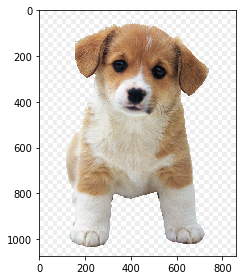

In [200]:
img = io.imread("puppy.png")

# Convert to RGB from RGBA (if applicable)
if img.ndim == 3 and img.shape[2] == 4:
    img = color.rgba2rgb(img)

print('Type:', type(img))
print('dtype:', img.dtype)
print('shape:', img.shape)
io.imshow(img)
print(img)

[[[0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  ...
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]]

 [[0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  ...
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]]

 [[0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  ...
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]]

 ...

 [[0.         0.         0.93333333]
  [0.         0.         0.93333333]
  [0.         0.         0.93333333]
  ...
  [0.         0.         0.93333333]
  [0.         0.         0.93333333]
  [0.         0.         0.93333333]]

 [[0.         0.         0.93333333]
  [0.         0.         0.93333333]


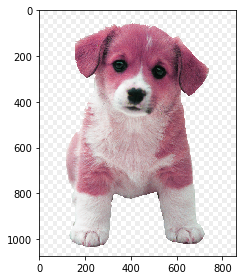

In [201]:
# color
img_hsv = color.rgb2hsv(img)
print(img_hsv)
img_hsv_m = img_hsv
img_hsv_m[:,:,0] -= 0.8
#io.imshow(img_hsv_m)
io.imshow(color.hsv2rgb(img_hsv_m))

---- After NORMALIZING ----
[[[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 [[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 [[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 ...

 [[0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  ...
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]]

 [[0.93333333 0.93333333 0.93333333]
  [0.9333

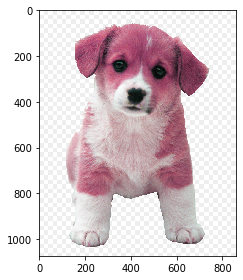

In [202]:
# Mine
img2_hsv = RGBtoHSV(img)
img2_hsv[:,:,0] -= 0.8
io.imshow(color.hsv2rgb(img2_hsv))

[[[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 [[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 [[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 ...

 [[0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  ...
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]]

 [[0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]


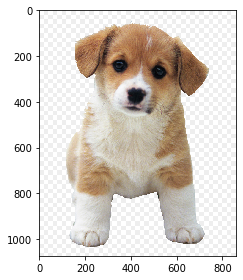

In [203]:
img = io.imread("puppy.png")
io.imshow(img)

# Convert to RGB from RGBA (if applicable)
if img.ndim == 3 and img.shape[2] == 4:
    img = color.rgba2rgb(img)
    
print(img)

[[[0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  ...
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]]

 [[0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  ...
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]]

 [[0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  ...
  [0.         0.         1.        ]
  [0.         0.         1.        ]
  [0.         0.         1.        ]]

 ...

 [[0.         0.         0.93333333]
  [0.         0.         0.93333333]
  [0.         0.         0.93333333]
  ...
  [0.         0.         0.93333333]
  [0.         0.         0.93333333]
  [0.         0.         0.93333333]]

 [[0.         0.         0.93333333]
  [0.         0.         0.93333333]


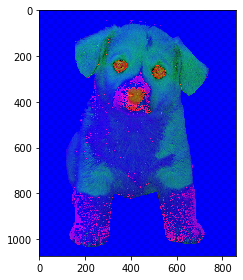

In [204]:
img_hsv = color.rgb2hsv(img)
print(img_hsv)
io.imshow(img_hsv)

[[[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 [[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 [[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 ...

 [[0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  ...
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]]

 [[0.93333333 0.93333333 0.93333333]
  [0.93333333 0.93333333 0.93333333]


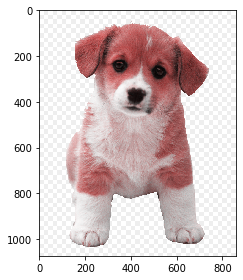

In [205]:
img_hsv = HSVtoRGB(img_hsv)
print(img_hsv)
io.imshow(img_hsv)